In [ ]:
# Importing packages necessary for my analysis.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Viewing the dataset.
data  = pd.read_csv('data/Gh_house_rentals.csv')
data.head()

,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,amenities,region,locality,parking_space,is_furnished,lat,lng
0,https://tonaton.com/a-MfYFNdCgCTytOcmvZIh0Kzrj...,rentals,"2bdrm Apartment in Charclem Ventures, East Leg...",9196.0,Flats,2,2,145.0,"Greater Accra, East Legon",Used,"24-hour Electricity,Air Conditioning,Balcony,C...",Greater Accra,East Legon,False,Semi-Furnished,5.635828,-0.161359
1,https://tonaton.com/a-MfYFNdCgwtb8Itol9odpMPvC...,rentals,"2bdrm Apartment in , Dzorwulu for rent",7500.0,Flats,2,2,100.0,"Greater Accra, Dzorwulu",Used,"24-hour Electricity,Air Conditioning,Apartment...",Greater Accra,Dzorwulu,False,Unfurnished,5.614123,-0.195647
2,https://tonaton.com/a-MfYFNdCgPjnzPYwNFEv5JrGy...,rentals,"4bdrm House in Lakeside Estate, for Rent",11200.0,Detached,4,5,100.0,"Greater Accra, Ashaley Botwe, Lake Side Estate",New,"Tiled Floor,Chandelier,Dining Area,Balcony,Pop...",Greater Accra,Ashaley Botwe,False,Semi-Furnished,5.680213,-0.137248
3,https://tonaton.com/a-MfYFNdCgwmXHQRNJiSR3rok8...,rentals,"3bdrm House in Ayathar Bedroom, Teshie for Rent",2500.0,Detached,3,3,17.0,"Greater Accra, Teshie",Used,"Pop Ceiling,Pre-Paid Meter,24-hour Electricity...",Greater Accra,Teshie,False,Semi-Furnished,5.583166,-0.104608
4,https://tonaton.com/a-MfYFNdCgn3Bcs511lKnFE19i...,rentals,"3bdrm House in Manet Viile Estate, Spintex for...",9146.0,Detached,3,3,160.0,"Greater Accra, Spintex",Used,"Pre-Paid Meter,Dining Area,Chandelier,Balcony,...",Greater Accra,Spintex,False,Semi-Furnished,5.637614,-0.126606


In [22]:
data.describe()

,price,bedrooms,bathrooms,floor_area,lat,lng
count,18199.000000,18263.000000,18263.000000,18221.000000,18263.000000,18263.000000
mean,7986.791857,2.459618,2.565405,556.611053,5.725899,-0.246991
std,10391.854437,1.263888,1.378759,1045.060765,0.453726,0.322948
min,416.000000,1.000000,1.000000,10.000000,4.849041,-2.579248
25%,1700.000000,2.000000,1.000000,100.000000,5.592619,-0.215087
50%,3500.000000,2.000000,2.000000,145.000000,5.637614,-0.161359
75%,9800.000000,3.000000,3.000000,600.000000,5.682581,-0.135459
max,59524.000000,20.000000,20.000000,5000.000000,9.410999,0.563609


### Handling Missing Values

In [ ]:
# Dropping the missing values for price and amenities as they are crucial for analysis.
data['price'] = data['price'].dropna()
data['amenities'] = data['amenities'].dropna()

# Filling missing values for name with 'Unknown' and floor_area with median value.
data['name'] = data['name'].fillna('Unknown')
data['floor_area'] = data['floor_area'].fillna(data['floor_area'].median())

# Dropping duplicates.
data = data.drop_duplicates()
data.head()

,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,amenities,region,locality,parking_space,is_furnished,lat,lng
0,https://tonaton.com/a-MfYFNdCgCTytOcmvZIh0Kzrj...,rentals,"2bdrm Apartment in Charclem Ventures, East Leg...",9196.0,Flats,2,2,145.0,"Greater Accra, East Legon",Used,"24-hour Electricity,Air Conditioning,Balcony,C...",Greater Accra,East Legon,False,Semi-Furnished,5.635828,-0.161359
1,https://tonaton.com/a-MfYFNdCgwtb8Itol9odpMPvC...,rentals,"2bdrm Apartment in , Dzorwulu for rent",7500.0,Flats,2,2,100.0,"Greater Accra, Dzorwulu",Used,"24-hour Electricity,Air Conditioning,Apartment...",Greater Accra,Dzorwulu,False,Unfurnished,5.614123,-0.195647
2,https://tonaton.com/a-MfYFNdCgPjnzPYwNFEv5JrGy...,rentals,"4bdrm House in Lakeside Estate, for Rent",11200.0,Detached,4,5,100.0,"Greater Accra, Ashaley Botwe, Lake Side Estate",New,"Tiled Floor,Chandelier,Dining Area,Balcony,Pop...",Greater Accra,Ashaley Botwe,False,Semi-Furnished,5.680213,-0.137248
3,https://tonaton.com/a-MfYFNdCgwmXHQRNJiSR3rok8...,rentals,"3bdrm House in Ayathar Bedroom, Teshie for Rent",2500.0,Detached,3,3,17.0,"Greater Accra, Teshie",Used,"Pop Ceiling,Pre-Paid Meter,24-hour Electricity...",Greater Accra,Teshie,False,Semi-Furnished,5.583166,-0.104608
4,https://tonaton.com/a-MfYFNdCgn3Bcs511lKnFE19i...,rentals,"3bdrm House in Manet Viile Estate, Spintex for...",9146.0,Detached,3,3,160.0,"Greater Accra, Spintex",Used,"Pre-Paid Meter,Dining Area,Chandelier,Balcony,...",Greater Accra,Spintex,False,Semi-Furnished,5.637614,-0.126606


In [32]:
for i in ['region','condition','is_furnished', 'category']:
    print(f'{i}: {data[i].unique()}')

region: ['Greater Accra' 'Ashanti' 'Eastern Region' 'Central Region'
 'Northern Region' 'Western Region' 'Brong Ahafo' 'Volta Region']
condition: ['Used' 'New' 'Renovated']
is_furnished: ['Semi-Furnished' 'Unfurnished' 'Furnished']
category: ['Flats' 'Detached' 'Townhouse' 'Duplex' 'Mansion' 'Semi-Detached']


In [36]:
data[data.duplicated()]

,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,amenities,region,locality,parking_space,is_furnished,lat,lng
18020,https://tonaton.com/a-MfYFNdCgDX3OfDgzFAzM4TVr...,rentals,"2bdrm Apartment in Onuel Properties, Spintex f...",12400.0,Flats,2,2,1000.0,"Greater Accra, Spintex",Renovated,"24-hour Electricity,Air Conditioning,Apartment...",Greater Accra,Spintex,False,Semi-Furnished,5.637614,-0.126606
18036,https://tonaton.com/a-MfYFNdCgIpTlw6grNF9X37jF...,rentals,"4bdrm House in E a Properties, Housing Down fo...",3500.0,Detached,4,5,100.0,"Greater Accra, Adenta, Housing Down",Used,"24-hour Electricity,Air Conditioning,Balcony,C...",Greater Accra,Adenta,False,Semi-Furnished,5.706783,-0.150732
18092,https://tonaton.com/a-MfYFNdCgZZsBaVx9W8PYAmze...,rentals,"Furnished 2bdrm Apartment in Santasi Anyinam, ...",16000.0,Flats,2,2,14.0,"Ashanti, Kumasi Metropolitan",New,"24-hour Electricity,Air Conditioning,Apartment...",Ashanti,Kumasi Metropolitan,False,Furnished,6.693217,-1.627507
18096,https://tonaton.com/a-MfYFNdCgGX5HViJe1qZOPfaI...,rentals,"Furnished 2bdrm Apartment in Osu, Accra Metrop...",25000.0,Flats,2,3,900.0,"Greater Accra, Accra Metropolitan",Used,"24-hour Electricity,Air Conditioning,Apartment...",Greater Accra,Accra Metropolitan,False,Furnished,5.545941,-0.210399


<Axes: ylabel='floor_area'>

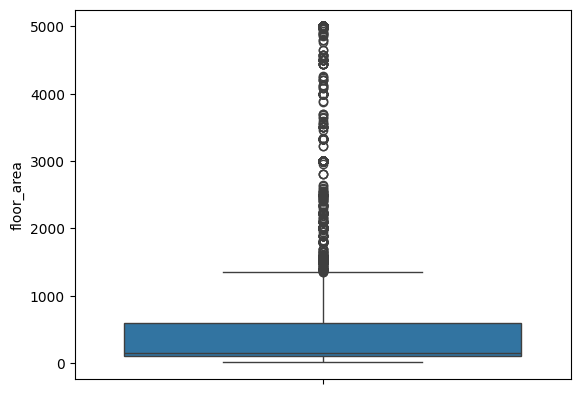

In [24]:
sns.boxplot(data['floor_area'])